In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal, interpolate
import glob
import gsw
from datetime import timedelta
import warnings
#%matplotlib widget

## Aquadopp clock analysis & correction
Let's open our files : 
- Aquadopp with apparent clock drift
- associated microcat with no clock drift
- we'll copy the Aquadopp dataset to apply correction

In [3]:
ds1 = xr.open_dataset('/mnt/scale/crossroad/MOORINGS/FC4/AQD/FC4_Aquadopp_11274-aqd.nc')
ds2 = xr.open_dataset('/mnt/scale/crossroad/MOORINGS/FC4/sbe37_microcat/25915.nc')
ds3 = ds1.copy()

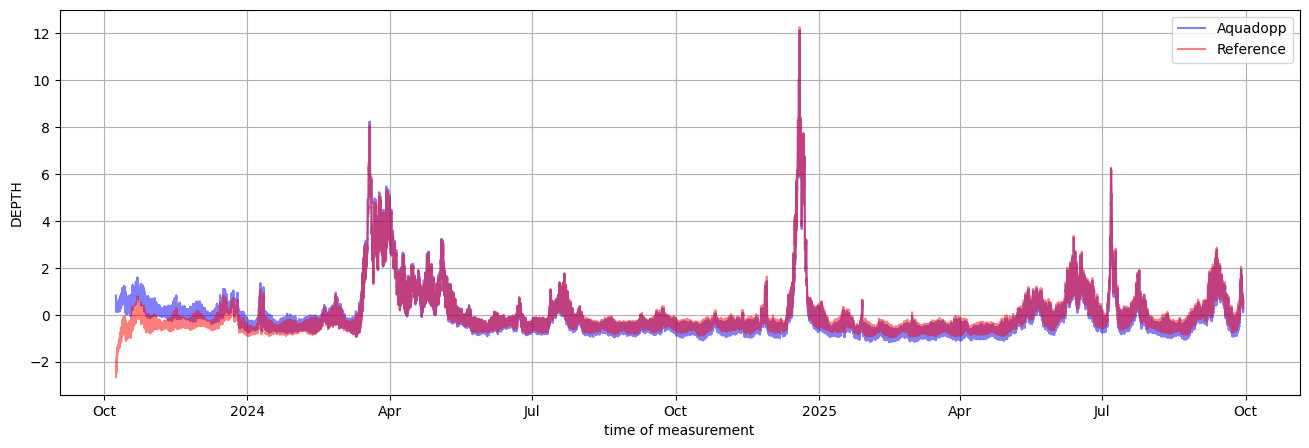

In [4]:
f,ax = plt.subplots(figsize=(16,5))
ax.grid()
A=ds1['DEPTH'].where(ds1['DEPTH_QC']<4)
(A-A.mean()).plot.line('-b',alpha=.5,ax=ax,label='Aquadopp')
B=ds2['DEPTH'].where(ds2['DEPTH_QC']<4)
(B-B.mean()).plot.line('-r',alpha=.5,ax=ax, label='Reference')
plt.legend()

### Let's build an xarray dataset to facilitate our delay calculation

In [5]:
A=ds1['DEPTH'].where(ds1['DEPTH_QC']<4)
B=ds2['DEPTH'].where(ds2['DEPTH_QC']<4)
BL = B.dropna('TIME').interp(TIME=A.TIME,method='linear').dropna('TIME')
AL = A.dropna('TIME').interp(TIME=BL.TIME,method='linear').dropna('TIME')

In [6]:
ds = xr.Dataset({'DEPTH':(['TIME','NS'],np.vstack([AL.values,BL.values]).transpose())},{'TIME':AL.TIME.values})
ds

<xarray.Dataset> Size: 2MB
Dimensions:  (TIME: 103893, NS: 2)
Coordinates:
  * TIME     (TIME) datetime64[ns] 831kB 2023-10-08T21:39:59.999997952 ... 20...
Dimensions without coordinates: NS
Data variables:
    DEPTH    (TIME, NS) float64 2MB 3.903e+03 3.897e+03 ... 3.903e+03 3.9e+03

### Let's illustrate the clock drift with 2 windows, one at the beginning and one at the end of the serie

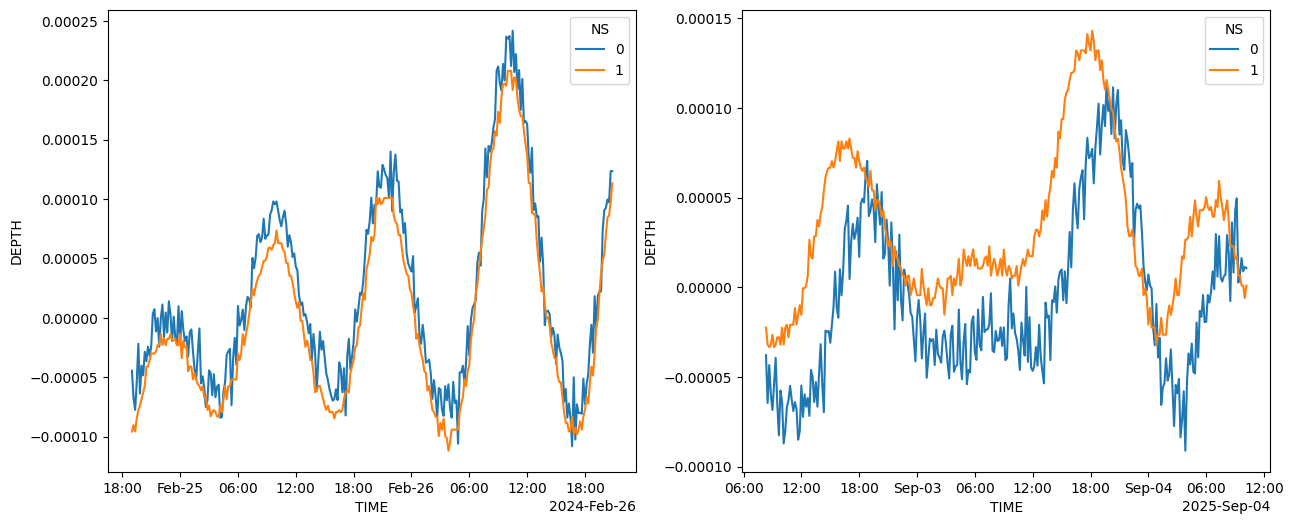

In [7]:
K=(ds['DEPTH']-ds['DEPTH'].mean('TIME'))/(ds['DEPTH'].max('TIME'))
f,ax = plt.subplots(1,2,figsize=(15,6))
K.isel(TIME=slice(20000,20300)).plot(hue='NS',ax=ax[0],)
K.isel(TIME=slice(100000,100300)).plot(hue='NS',ax=ax[1],)

### Let's make a function to calculate the estimated delay between 2 signals and apply it by chunks with `coarsen` & `reduce`

Text(0, 0.5, 'Phase delay estimate (seconds)')

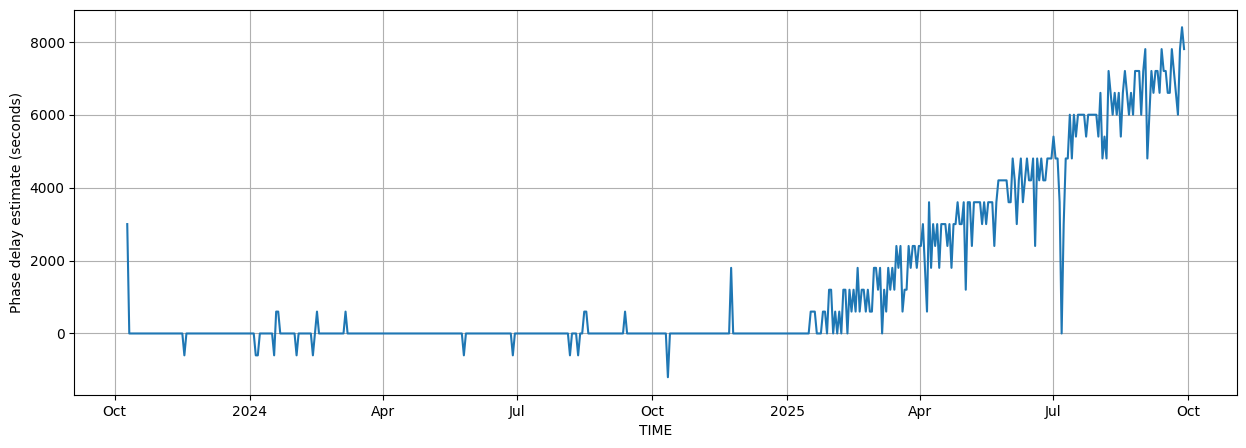

In [8]:
# Coarsen reduce only work with numpy arrays
from scipy.ndimage import uniform_filter1d
def mdelayc(x, axis=None):
    # X dimensions : N_GROUP, DATA WITHIN THE GROUP (T,N)
    # Since we use 2 dimensions input (2 signals), the output has to be 2 dim (we'll leave one at 0)
    output = np.zeros([x.shape[0],x.shape[2]]) 
    # Let's loop over coarsen groups
    for k in range(x.shape[0]):
        x1 = x[k,:,0]
        y1 = x[k,:,1]
        x1 = (x1-np.mean(x1))/np.max(x1) # norm
        y1 = (y1-np.mean(y1))/np.max(y1)
        x1 = uniform_filter1d(x1, 10, mode='nearest')[10:-10] # filter with a 10 points sliding mean
        y1 = uniform_filter1d(y1, 10, mode='nearest')[10:-10]
        correlation = signal.correlate(x1, y1, mode="full") # scipy correlation
        lags = signal.correlation_lags(x1.size, y1.size, mode="full") # scipy lags 
        output[k,0] = lags[np.argmax(correlation)] # store lag calculation for this group
    return output
# apply and keep the 1st column    
mdelay = ds['DEPTH'].coarsen(TIME=200, boundary="trim").reduce(mdelayc).isel(NS=0)

f,ax = plt.subplots(1,1,figsize=(15,5))
(mdelay*600).plot(ax=ax) # dt = 600 sec
ax.grid()
ax.set_ylabel('Phase delay estimate (seconds)')

### Now let's correct linearly our clock, beginning at a certain date

In [9]:
tds=np.zeros(len(ds1['TIME'].values),dtype='timedelta64[s]')
ix = np.argmin(np.abs(ds1['TIME'].values - np.datetime64('2025-02-01')))
tds[ix:] = np.linspace(0,8000,len(tds[ix:]))

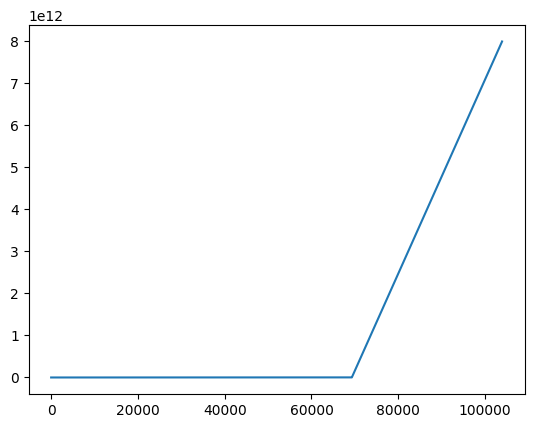

In [10]:
plt.plot(tds.astype('timedelta64[ns]'))

In [11]:
# We'll use our copy dataset from here
ds3 = ds3.assign_coords(TIME= (ds3['TIME'].values - tds.astype('timedelta64[ns]')))

### Let's recompare with the reference microcat

In [12]:
C = ds3['DEPTH'].where(ds3['DEPTH_QC']<4)
BL = B.dropna('TIME').interp(TIME=C.TIME,method='linear').dropna('TIME')
CL = C.dropna('TIME').interp(TIME=BL.TIME,method='linear').dropna('TIME')

delay : 0  seconds


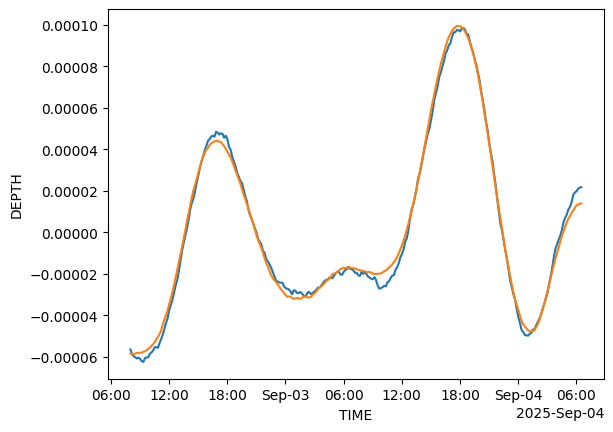

In [13]:
# Take a point at the end of the time serie
i=100000
window = 300
x = ((CL[i:i+window] - CL[i:i+window].mean())/CL[i:i+window].max()).rolling(TIME=20,center=True).mean()[10:-10]
y = ((BL[i:i+window] - BL[i:i+window].mean())/BL[i:i+window].max()).rolling(TIME=20,center=True).mean()[10:-10]
x.plot()
y.plot()
correlation = signal.correlate(x, y, mode="full")
lags = signal.correlation_lags(x.size, y.size, mode="full")
lag = lags[np.argmax(correlation)]
print("delay :",lag*600,' seconds')

### Let's re-estimate the lag now

Text(0, 0.5, 'Phase delay estimate (seconds)')

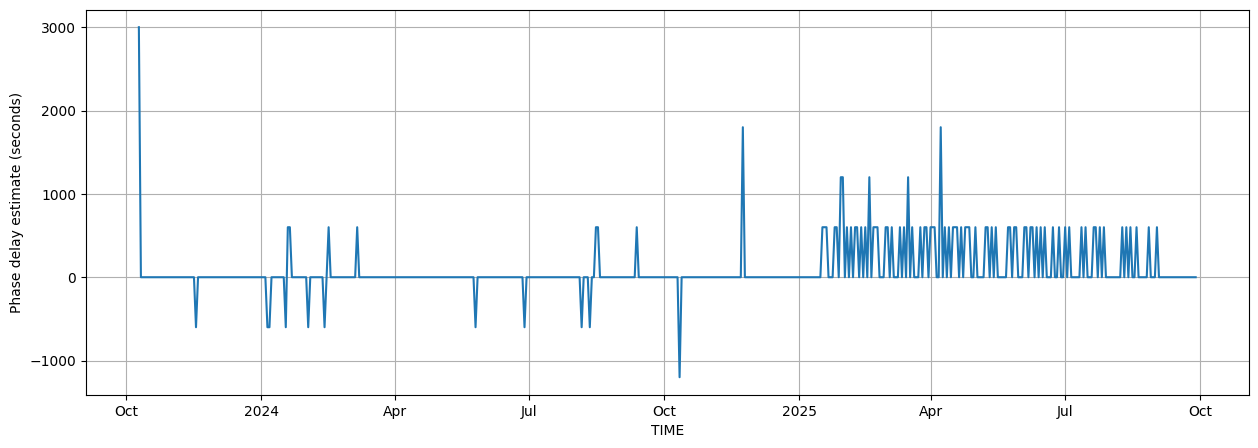

In [15]:
ds2 = xr.Dataset({'DEPTH':(['TIME','NS'],np.vstack([CL.values,BL.values]).transpose())},{'TIME':CL.TIME.values})
mdelay2 = ds2['DEPTH'].coarsen(TIME=200, boundary="trim").reduce(mdelayc).isel(NS=0)

f,ax = plt.subplots(1,1,figsize=(15,5))
(mdelay2*600).plot(ax=ax) # dt = 600 sec
ax.grid()
ax.set_ylabel('Phase delay estimate (seconds)')

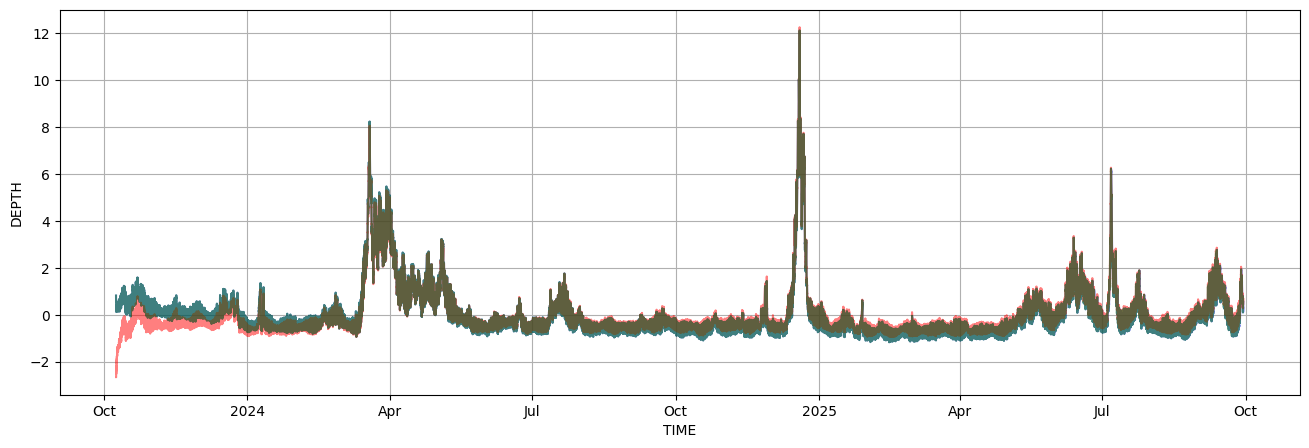

In [14]:
f,ax = plt.subplots(figsize=(16,5))
ax.grid()
A=ds1['DEPTH'].where(ds1['DEPTH_QC']<4)
(A-A.mean()).plot.line('-b',alpha=.5,ax=ax)
B=ds2['DEPTH'].where(ds2['DEPTH_QC']<4)
(B-B.mean()).plot.line('-r',alpha=.5,ax=ax)
C=ds3['DEPTH'].where(ds3['DEPTH_QC']<4)
(C-C.mean()).plot.line('-g',alpha=.5,ax=ax)

### Save new file

In [269]:
#ds3.to_netcdf('/mnt/scale/crossroad/MOORINGS/FC4/AQD/FC4_Aquadopp_11274_corrected.nc')